# Search interest and weekly social engagement

Do weekly Google Trends indexes move with Twitter engagement after a linear time trend is included?

This notebook calls `analysis.py`. It runs on the **synthetic sample** in `data/sample/` (NumPy seed 42). Those files are generated counts and indexes, marked with a `# SYNTHETIC DATA` header. They are here so the pipeline can execute.

The published fits, from the OLS tables saved on **6 November 2024**, are:

- IVCT MPF: `tweet_count ~ Corruption + time`, **R² = 0.053**, **n = 366**
- IVCT Delta: `influence_score ~ Car Wash Operations + time`, **R² = 0.272**, **n = 362**

Full definitions, data schema, and residual caveats are in the README. The R² printed by the cells below belongs to the synthetic sample.

## 1. Load the sample and merge on the week

Trends week labels and tweet timestamps are parsed to naive UTC. Tweets are resampled to weeks ending Sunday.

In [1]:
from IPython.display import display

import matplotlib.pyplot as plt

import analysis


def show_figure(fig):
    """Embed one figure, then close it so the inline backend does not repeat it."""
    display(fig)
    plt.close(fig)


trends = analysis.load_trends(analysis.DEFAULT_TRENDS_PATH)
series = []
for path in analysis.DEFAULT_TWEET_PATHS:
    name = path.stem.replace("twitter_", "").replace("_", " ")
    tweets = analysis.load_tweets(path)
    result = analysis.analyze_series(trends, tweets, window=12)
    series.append((name, result))
    print(f"{name}: {len(tweets)} synthetic tweets, {len(result['merged'])} overlapping weeks")

display(series[0][1]["merged"].head())


alpha: 156 synthetic tweets, 60 overlapping weeks
beta: 145 synthetic tweets, 60 overlapping weeks


,Corruption,Car Wash Operations,Economy,isPartial,retweet_count,like_count,quote_count,influence_score,tweet_count
week,,,,,,,,,
2020-01-05,26.2,13.0,55.4,0,10,44,7,20.333333,2
2020-01-12,22.2,17.1,59.6,0,18,15,1,11.333333,1
2020-01-19,30.6,18.8,59.7,0,23,9,0,10.666667,1
2020-01-26,32.6,20.2,63.5,0,20,35,0,18.333333,1
2020-02-02,22.1,20.7,61.5,0,34,61,6,33.666667,3


## 2. Influence score

For each Sunday-ending week the script sums retweets, likes, and quotes, then sets

`influence_score = (retweet_count + like_count + quote_count) / 3`.

`tweet_count` is the number of tweets in that week. The score uses weekly sums, so a large like count dominates a small quote count.

In [2]:
weekly_columns = ["retweet_count", "like_count", "quote_count", "influence_score", "tweet_count"]
display(series[0][1]["weekly"][weekly_columns].head())

,retweet_count,like_count,quote_count,influence_score,tweet_count
week,,,,,
2020-01-05,10,44,7,20.333333,2
2020-01-12,18,15,1,11.333333,1
2020-01-19,23,9,0,10.666667,1
2020-01-26,20,35,0,18.333333,1
2020-02-02,34,61,6,33.666667,3


## 3. Weekly correlation matrix

`isPartial` is excluded. High correlations among retweets, likes, quotes, the influence score, and tweet count are expected, because those columns are built from the same tweets.

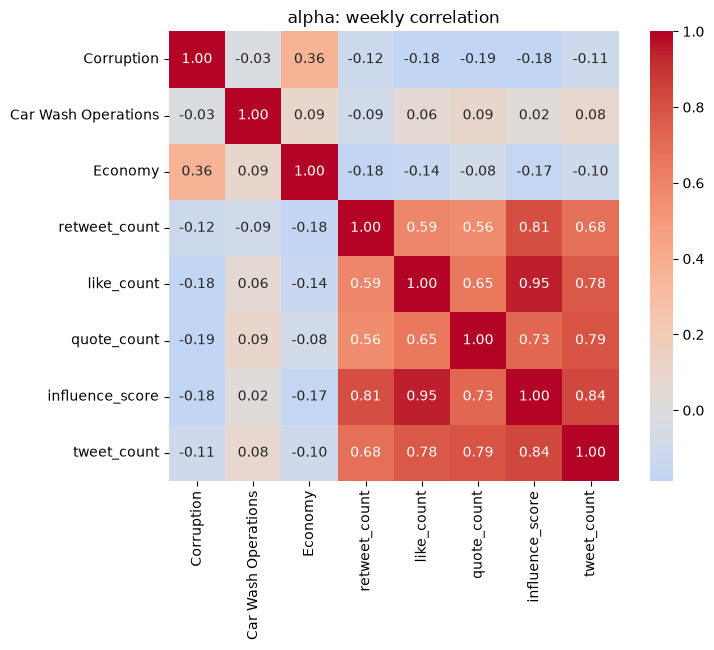

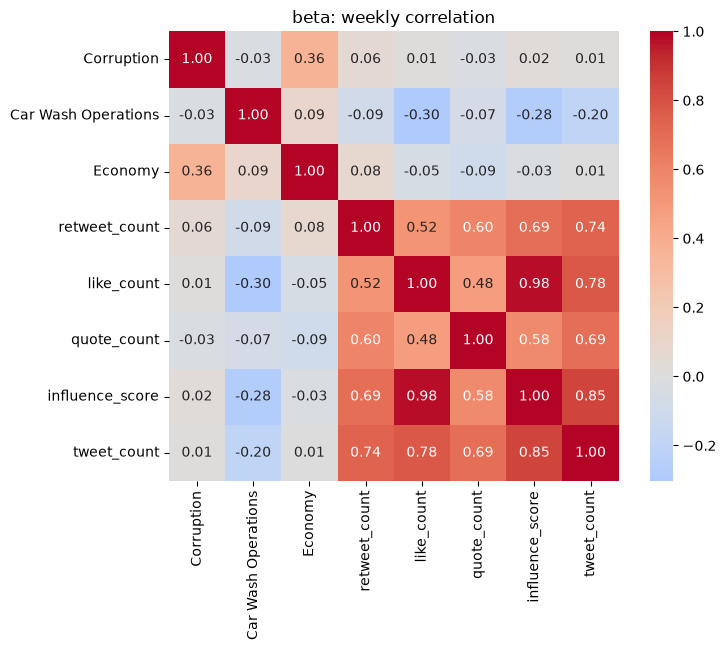

In [3]:
for name, result in series:
    show_figure(analysis.plot_correlation_heatmap(result["merged"], f"{name}: weekly correlation"))


## 4. Rolling correlation

Each point is the Pearson correlation inside a trailing 12-week window. The first 11 weeks are blank because the window is not full yet. `rolling_correlation(..., as_panel=True)` returns the whole correlation matrix for every window.

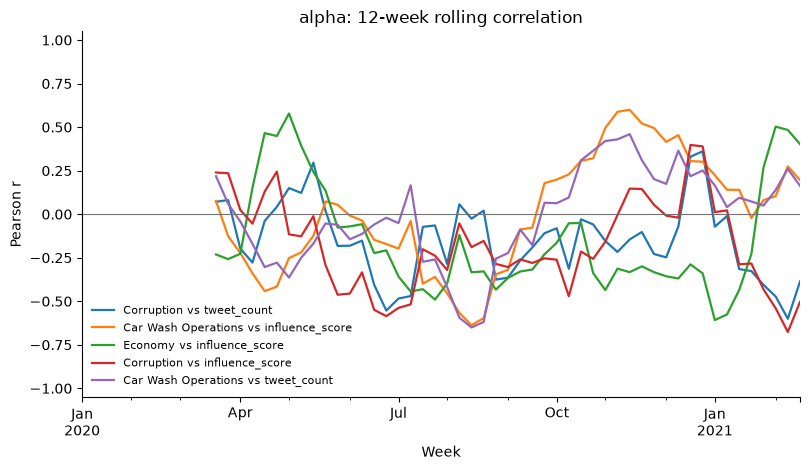

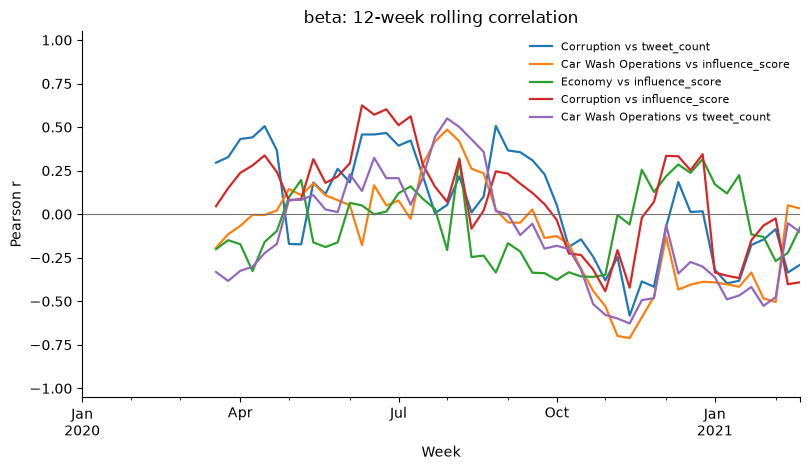

In [4]:
for name, result in series:
    show_figure(
        analysis.plot_rolling_correlation(
            result["rolling"],
            f"{name}: {result['window']}-week rolling correlation",
        )
    )


## 5. OLS with a time-trend control

The scatter trend line is bivariate. The regression also includes `time`, the number of days since the first week in the merged panel. On the original extracts the saved fits were R² = 0.053 (n = 366) and R² = 0.272 (n = 362). The summaries below are the same specifications on the synthetic sample.

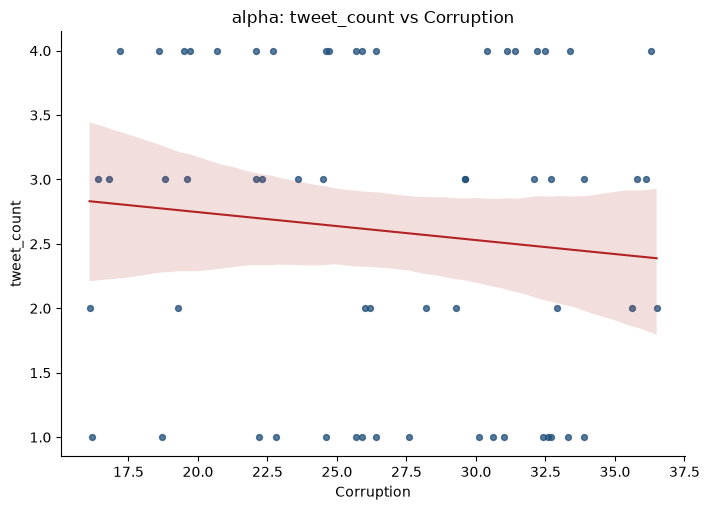

alpha: tweet_count ~ Corruption + time
                            OLS Regression Results                            
Dep. Variable:            tweet_count   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.4094
Date:                Tue, 06 Oct 2026   Prob (F-statistic):              0.666
Time:                        09:27:08   Log-Likelihood:                -95.648
No. Observations:                  60   AIC:                             197.3
Df Residuals:                      57   BIC:                             203.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

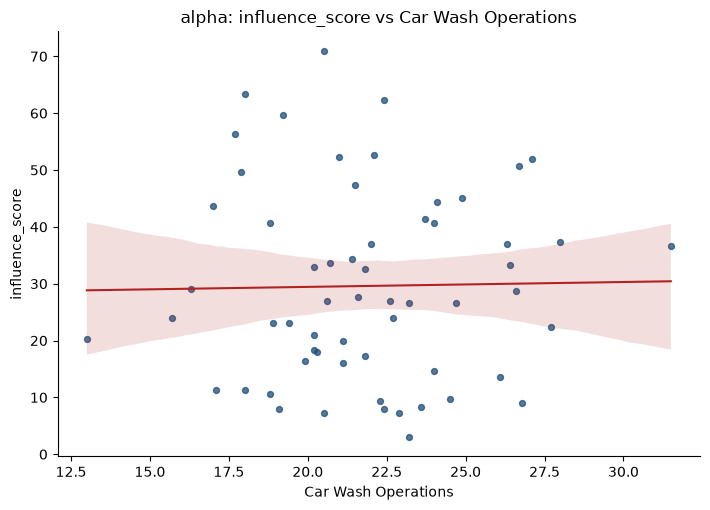

alpha: influence_score ~ Car Wash Operations + time
                            OLS Regression Results                            
Dep. Variable:        influence_score   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.032
Method:                 Least Squares   F-statistic:                   0.08940
Date:                Tue, 06 Oct 2026   Prob (F-statistic):              0.915
Time:                        09:27:08   Log-Likelihood:                -253.84
No. Observations:                  60   AIC:                             513.7
Df Residuals:                      57   BIC:                             520.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

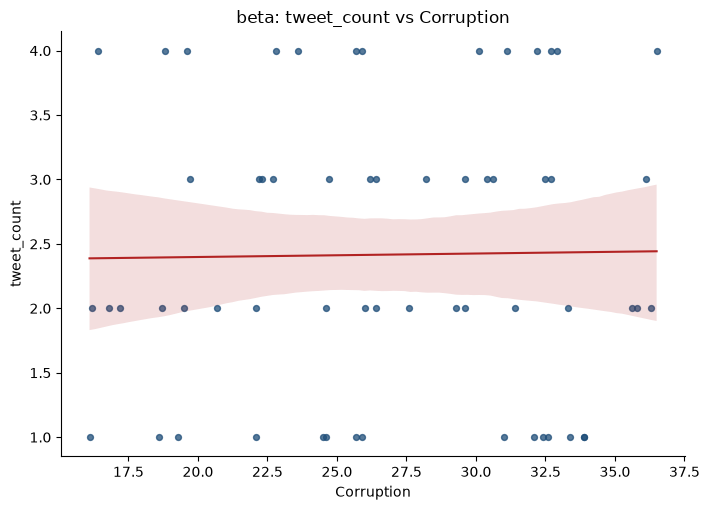

beta: tweet_count ~ Corruption + time
                            OLS Regression Results                            
Dep. Variable:            tweet_count   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9665
Date:                Tue, 06 Oct 2026   Prob (F-statistic):              0.387
Time:                        09:27:08   Log-Likelihood:                -89.009
No. Observations:                  60   AIC:                             184.0
Df Residuals:                      57   BIC:                             190.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

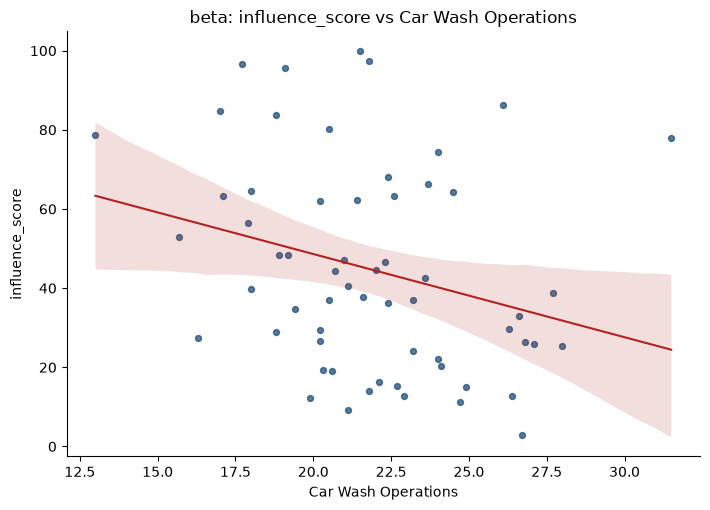

beta: influence_score ~ Car Wash Operations + time
                            OLS Regression Results                            
Dep. Variable:        influence_score   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     3.324
Date:                Tue, 06 Oct 2026   Prob (F-statistic):             0.0431
Time:                        09:27:08   Log-Likelihood:                -277.06
No. Observations:                  60   AIC:                             560.1
Df Residuals:                      57   BIC:                             566.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [5]:
for name, result in series:
    for (independent, dependent), model in result["models"].items():
        show_figure(
            analysis.plot_scatter_with_trendline(
                result["merged"],
                independent,
                dependent,
                f"{name}: {dependent} vs {independent}",
            )
        )
        print(f"{name}: {dependent} ~ {independent} + time")
        print(model.summary())


## 6. How to read the published fits

On the private extracts, R² = 0.053 means the Corruption index and a linear time trend together explain about five percent of weekly IVCT MPF tweet counts. R² = 0.272 on IVCT Delta is stronger and still leaves most of the influence-score variance unexplained. In that second equation the time coefficient is very precisely estimated, so a good share of the explained part is common drift.

Both original summaries fail residual checks: skewness of 2.163 and 4.147, kurtosis of 14.331 and 30.545, Durbin–Watson of 1.241 and 1.133, and condition numbers around 3.6e3. Classical p-values from those tables overstate precision. Charts from that run are in `figures/`.